In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

In [3]:
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import os
from collections import Counter
from sklearn.model_selection import train_test_split

In [5]:
dataset_path = "/kaggle/input/datasets/yidazhang07/bridge-cracks-image"

In [6]:
import os

# Define your Kaggle dataset root path
dataset_root = "/kaggle/input/datasets/yidazhang07/bridge-cracks-image"

# Supported image extensions
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

# Dictionary to hold categories and their nested image paths
category_image_map = {}

# 1. Start scanning the root folder
for entry in os.scandir(dataset_root):
    if entry.is_dir():
        category_name = entry.name
        category_image_map[category_name] = []
        
        # 2. Use os.walk to recursively hunt for images at any depth level
        for root, dirs, files in os.walk(entry.path):
            for file in files:
                if file.lower().endswith(valid_extensions):
                    # 3. Create the absolute path safely
                    full_path = os.path.join(root, file)
                    category_image_map[category_name].append(full_path)

# Quick summary of what we found
for category, paths in category_image_map.items():
    print(f"Category '{category}': Found {len(paths)} nested images.")


Category 'Bridge_Crack_Image': Found 55000 nested images.
Category 'CrackForest': Found 310 nested images.
Category 'Magnetic-Tile-Defect': Found 863 nested images.
Category 'DeepPCB': Found 3021 nested images.


In [7]:
import os
import pandas as pd
from PIL import Image


data_summary = []

for category, paths in category_image_map.items():
    for path in paths:
        try:
            # open() only reads the file header, making it incredibly fast
            with Image.open(path) as img:
                width, height = img.size
                channels = len(img.getbands()) # 3 for RGB, 1 for Grayscale
                
                data_summary.append({
                    'category': category,
                    'file_name': os.path.basename(path),
                    'path': path,
                    'width': width,
                    'height': height,
                    'channels': channels,
                    'aspect_ratio': round(width / height, 2),
                    'status': 'Valid'
                })
        except Exception as e:
            # Catches corrupted images, truncated files, or unreadable formats
            data_summary.append({
                'category': category,
                'file_name': os.path.basename(path),
                'path': path,
                'width': None, 'height': None, 'channels': None, 'aspect_ratio': None,
                'status': f'Corrupted/Error: {str(e)}'
            })

# Convert to DataFrame for quick analysis
df = pd.DataFrame(data_summary)




In [9]:
df.describe

<bound method NDFrame.describe of                  category          file_name  \
0      Bridge_Crack_Image         no335.jpeg   
1      Bridge_Crack_Image      crack323.jpeg   
2      Bridge_Crack_Image        no2497.jpeg   
3      Bridge_Crack_Image      crack750.jpeg   
4      Bridge_Crack_Image        no3111.jpeg   
...                   ...                ...   
59189             DeepPCB  12100001_temp.jpg   
59190             DeepPCB  12100002_temp.jpg   
59191             DeepPCB  12100002_test.jpg   
59192             DeepPCB         eraser.png   
59193             DeepPCB            pen.png   

                                                    path  width  height  \
0      /kaggle/input/datasets/yidazhang07/bridge-crac...     16      16   
1      /kaggle/input/datasets/yidazhang07/bridge-crac...     16      16   
2      /kaggle/input/datasets/yidazhang07/bridge-crac...     16      16   
3      /kaggle/input/datasets/yidazhang07/bridge-crac...     16      16   
4      /kaggle

In [10]:
for root, dirs, files in os.walk(dataset_path):
    print(f"Folder: {root}")
    print(f"Subdirs: {dirs}")
    print(f"Files: {files}")
    print("\n")

Folder: /kaggle/input/datasets/yidazhang07/bridge-cracks-image
Subdirs: ['Bridge_Crack_Image', 'CrackForest', 'Magnetic-Tile-Defect', 'DeepPCB']
Files: []


Folder: /kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image
Subdirs: ['DBCC_Training_Data_Set']
Files: ['README.md', 'DBCC_quick_train_test.prototxt', 'DBCC_quick_solver.prototxt']


Folder: /kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image/DBCC_Training_Data_Set
Subdirs: ['val', 'train']
Files: ['val.txt', 'train.txt']


Folder: /kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image/DBCC_Training_Data_Set/val
Subdirs: []
Files: ['no335.jpeg', 'crack323.jpeg', 'no2497.jpeg', 'crack750.jpeg', 'no3111.jpeg', 'crack149.jpeg', 'crack380.jpeg', 'crack6.jpeg', 'no2435.jpeg', 'no1372.jpeg', 'crack622.jpeg', 'no3512.jpeg', 'no2990.jpeg', 'no1300.jpeg', 'no749.jpeg', 'no3698.jpeg', 'no2009.jpeg', 'no2906.jpeg', 'crack760.jpeg', 'no1924.jpeg', 'crack264.jpeg', 'no1079.jpeg', 'n

In [14]:
print(dataset_path)
for class_name in os.listdir(dataset_path):
    print(class_name)

/kaggle/input/datasets/yidazhang07/bridge-cracks-image
Bridge_Crack_Image
CrackForest
Magnetic-Tile-Defect
DeepPCB


### current working Directory

In [15]:
import os
print(os.getcwd())
c=os.listdir("/kaggle/working")
print(c)


/kaggle/working
['.virtual_documents']


### Scan Current Folder

In [17]:
for entry in os.scandir('.'):
    print(entry.name, 'File' if entry.is_file() else 'Folder')



.virtual_documents Folder


In [18]:
import os
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")
img_dir_path="/kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image/DBCC_Training_Data_Set/train"

data = []

for class_name in os.listdir(dataset_path):
    # print(class_name)

    class_folder = os.path.join(dataset_path, class_name)
    # print(class_folder)
    print("\n--- ",class_folder,"\n")

    #inside the Class-folders
    for sub_dir in os.scandir(class_folder):

        
        print(sub_dir)
       
    
    if os.path.isdir(class_folder):

        for img in os.listdir("/kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image/DBCC_Training_Data_Set/train"):
            # print(os.listdir(class_folder))
            

            if img.lower().endswith(image_extensions):

                data.append({
                    "filepath": os.path.join(class_folder, img),
                    "label": class_name
                })

df = pd.DataFrame(data)


---  /kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image 

<DirEntry 'README.md'>
<DirEntry 'DBCC_quick_train_test.prototxt'>
<DirEntry 'DBCC_Training_Data_Set'>
<DirEntry 'DBCC_quick_solver.prototxt'>

---  /kaggle/input/datasets/yidazhang07/bridge-cracks-image/CrackForest 

<DirEntry 'README.md'>
<DirEntry 'groundTruth'>
<DirEntry 'seg'>
<DirEntry 'image'>

---  /kaggle/input/datasets/yidazhang07/bridge-cracks-image/Magnetic-Tile-Defect 

<DirEntry 'MT_Fray'>
<DirEntry 'MT_Break'>
<DirEntry 'MT_Crack'>
<DirEntry 'MT_Free'>
<DirEntry 'MT_Blowhole'>

---  /kaggle/input/datasets/yidazhang07/bridge-cracks-image/DeepPCB 

<DirEntry 'fig'>
<DirEntry 'LICENSE'>
<DirEntry '.gitignore'>
<DirEntry 'PCBData'>
<DirEntry 'README.md'>
<DirEntry 'tools'>
<DirEntry 'evaluation'>


In [20]:
print(df.columns)

Index(['filepath', 'label'], dtype='object')


## DataFrame Information About the dataset

In [21]:
df.describe

<bound method NDFrame.describe of                                                  filepath               label
0       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
1       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
2       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
3       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
4       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
...                                                   ...                 ...
199995  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199996  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199997  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199998  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199999  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB

[200000 rows x 2 columns]>

In [22]:
df.info

<bound method DataFrame.info of                                                  filepath               label
0       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
1       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
2       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
3       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
4       /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
...                                                   ...                 ...
199995  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199996  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199997  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199998  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB
199999  /kaggle/input/datasets/yidazhang07/bridge-crac...             DeepPCB

[200000 rows x 2 columns]>

## Totall Numbers of Images Avaible in Dataset

In [23]:
#totall images 
totall_images=len(df)
print(totall_images)

200000


## Numbers of Classes in Dataset

In [24]:
print(df["label"].unique())

['Bridge_Crack_Image' 'CrackForest' 'Magnetic-Tile-Defect' 'DeepPCB']


In [25]:
print(df.head(4))

                                            filepath               label
0  /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
1  /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
2  /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image
3  /kaggle/input/datasets/yidazhang07/bridge-crac...  Bridge_Crack_Image


In [26]:
print("Total Classes:", df["label"].nunique())

Total Classes: 4


## Count Images Per Class

In [27]:
class_count=df["label"].value_counts()
print(class_count)

label
Bridge_Crack_Image      50000
CrackForest             50000
Magnetic-Tile-Defect    50000
DeepPCB                 50000
Name: count, dtype: int64


## Percentage of Each Class in Dataset

In [28]:
percentage=df["label"].value_counts(normalize=True)*100
print(percentage)

label
Bridge_Crack_Image      25.0
CrackForest             25.0
Magnetic-Tile-Defect    25.0
DeepPCB                 25.0
Name: proportion, dtype: float64


## Is Dataset is balance or unbalance

In [29]:
check_balance=class_count.max() / class_count.min() 

if check_balance < 1.5:
    print(check_balance)
    print("Dataset is Balanced")
else :
    print(check_balance)
    print("Dataset is Unbalanced")

1.0
Dataset is Balanced


## Image Extension

## Split Dataset (73%, 17%, 10%)

In [31]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.27,
    stratify=df["label"],
    random_state=42
)

In [32]:
test_df, val_df = train_test_split(
    temp_df,
    test_size=10/27,
    stratify=temp_df["label"],
    random_state=42
)

In [33]:
print("Training:", len(train_df))
print("Testing :", len(test_df))
print("Validation:", len(val_df))

Training: 146000
Testing : 34000
Validation: 20000


In [34]:
print("Train")
print(train_df["label"].value_counts())

print()

print("Test")
print(test_df["label"].value_counts())

print()

print("Validation")
print(val_df["label"].value_counts())

Train
label
Magnetic-Tile-Defect    36500
Bridge_Crack_Image      36500
CrackForest             36500
DeepPCB                 36500
Name: count, dtype: int64

Test
label
Magnetic-Tile-Defect    8500
DeepPCB                 8500
Bridge_Crack_Image      8500
CrackForest             8500
Name: count, dtype: int64

Validation
label
CrackForest             5000
Bridge_Crack_Image      5000
Magnetic-Tile-Defect    5000
DeepPCB                 5000
Name: count, dtype: int64


In [35]:
train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)
val_df.to_csv("validation.csv", index=False)

## Image Dimension 

In [36]:
from PIL import Image
import pandas as pd

sizes = []

for path in df["filepath"]:
    print(path)
    try:
        img = Image.open(path)
        if img:
            print("image is there")
        sizes.append(img.size)
        break
    except:
        print("having issue ")
        break

size_df = pd.DataFrame(sizes, columns=["width","height"])

print(size_df.describe())

/kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image/no335.jpeg
having issue 
       width height
count      0      0
unique     0      0
top      NaN    NaN
freq     NaN    NaN


### Dimension checking of **Single** image 

In [37]:
path= df["filepath"]
path="/kaggle/input/datasets/yidazhang07/bridge-cracks-image/Bridge_Crack_Image/DBCC_Training_Data_Set/train/crack10.jpeg"
img=Image.open(path)
size=img.size
height , width = img.size
print(height,width)

16 16


# Loading Image 
## Weak 2

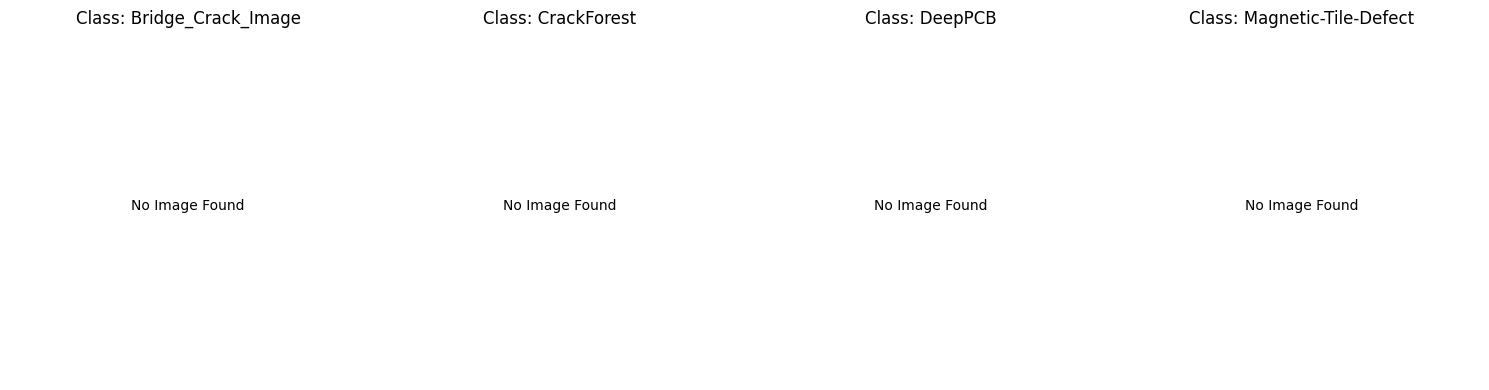

In [38]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# 1. Define the path to your Kaggle dataset
# Replace 'dataset-name' with your actual folder name inside input
DATASET_DIR = "/kaggle/input/datasets/yidazhang07/bridge-cracks-image"

# 2. Automatically get all category class names (folder names)
# This assumes your dataset is structured as: dataset/class_name/images.jpg
classes = [f for f in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, f))]
classes.sort()  # Sort alphabetically

# 3. Set up the matplotlib grid dynamically
num_classes = len(classes)
cols = 4  # Number of columns in the display grid
rows = (num_classes + cols - 1) // cols  # Calculate required rows

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()  # Flatten to easily loop through with a single index

# 4. Loop through each class and display exactly one random image
for i, class_name in enumerate(classes):
    class_path = os.path.join(DATASET_DIR, class_name)
    
    # Get all image files in the class folder
    all_images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if all_images:
        # Pick exactly one random image from the class
        random_image = random.choice(all_images)
        img_path = os.path.join(class_path, random_image)
        
        # Load and display the image
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"Class: {class_name}", fontsize=12)
        axes[i].axis('off')  # Hide the grid axes
    else:
        axes[i].text(0.5, 0.5, 'No Image Found', ha='center', va='center')
        axes[i].set_title(f"Class: {class_name}")
        axes[i].axis('off')

# 5. Hide any unused subplots in the grid
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
